# Question 3 Solutions

Please refer to README.ipynb for versions and required packages.

Considering the following 2-qubit Hamiltonian for the $H_{2}$ molecule:

$\hat{H} = −1.0523732458II + 0.3979374248IZ − 0.3979374248ZI − 0.0112801043ZZ + 0.1809311998XX$

where $II, IZ, ZI, ZZ, XX$ are tensor products of the corresponding Pauli operations

The variational ansatz is restricted to:

$\ket{\psi(\theta_1,\theta_2)} = (R_y(\theta_0) \otimes R_y(\theta_1))\ket{00}$

The exact ground state energy:

$E_0 = −1.85727503E_{h}$

## Part 1

### Declare variables and build ansatz

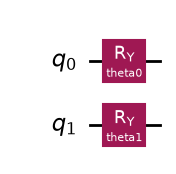

In [12]:
import numpy as np

n = 2 # number of qubits
e_ground = -1.85727503 # ground state energy

# DECLARE HAMILTONIAN

from qiskit.quantum_info import SparsePauliOp

hamiltonian = SparsePauliOp(['II','IZ','ZI','ZZ','XX'],coeffs=[-1.0523732458,0.3979374248,-0.3979374248,-0.0112801043,0.1809311998])

# BUILD ANSATZ

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

theta0 = Parameter('theta0')
theta1 = Parameter('theta1')

ansatz = QuantumCircuit(2) #ansatz has 2 qubits as we see in formula
ansatz.ry(theta0, 0) # rotation of theta_0 on first qubit
ansatz.ry(theta1, 1) # rotation of theta_1 on second qubit

ansatz.draw('mpl')

### VQE Implementation with Qiskit

In [15]:
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import VQE

estimator = Estimator()
optimizer = COBYLA()
vqe = VQE(estimator=estimator,ansatz=ansatz,optimizer=optimizer)

vqe_result = vqe.compute_minimum_eigenvalue(hamiltonian)
optimal_parameters = vqe_result.optimal_parameters

min_energy = vqe_result.eigenvalue.real

print(min_energy) # Minimum Energy
print(optimal_parameters) # Optimal Parameters


-1.8369679909836156
{Parameter(theta0): np.float64(9.424800648797042), Parameter(theta1): np.float64(2.475747396252303e-05)}


## Part 2

In [16]:
delta_e = min_energy - e_ground
print(delta_e)

0.02030703901638442


Notice the energy difference. The restricted ansatz cannot, in general, reach the exact ground-state energy of this Hamiltonian because, by definition, it restricts the quantum state only to a limited subspace of the Hilbert space. 

## Part 3

$R_y$ are single qubit rotations which means adding them would not remove the limitation explained in part 2. In order to remove the limitation, or atleast minimize it, we must increase our subspace. And given that the Hilbert space is multi-dimensional, if we wanted to increase our subspace we must apply quantum entanglement between the qubits, an entanglement layer like a chain of CNOT gates between neighboring qubits.